# 학습 내용
2. 전처리: 자연어의 노이즈 제거
자연어에 포함된 대표적인 세 가지 노이즈 유형을 확인하고 해결 방법을 학습합니다.
3. 분산표현: 바나나와 사과의 관계를 어떻게 표현할까?
분산표현이 무엇인지 희소표현과 같이 학습합니다.
4. 토큰화: 그녀는? 그녀+는?
대표적인 토큰화 기법인 공백, 형태소 기반 토큰화에 대하여 학습합니다.
5. 토큰화: 다른 방법들
OOV 문제를 해결한 BPE 그리고 BPE를 변형한 WPM에 대하여 학습합니다.
6. 토큰에게 의미를 부여하기
토큰화 기법이 아닌 단어 간 의미를 찾는 대표적인 세 가지 유형을 학습합니다.
# 학습 목표
분산 표현를 직관적으로 이해하고 이를 설명할 수 있습니다.
문장 데이터를 정제하는 방법을 사용할 수 있습니다.
토큰화의 여러 가지 기법들을 사용할 수 있습니다.
단어 Embedding을 구축하는 방법을 사용할 수 있습니다.

In [1]:
#!pip install konlpy
#!git clone https://github.com/SOMJANG/Mecab-ko-for-Google-Colab.git
#%cd Mecab-ko-for-Google-Colab/
#!bash install_mecab-ko_on_colab_light_220429.sh

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 40.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 50.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [konlpy]2m2/3 [konlpy]
Cloning into 'Mecab-ko-for-Google-Colab'...
remote: Enumerating objects: 138, done.
remote: Counting objects: 100% (47/47), done.
remote: Compressing objects: 100% (38/38), done.
remote: Total 138 (delta 26), reused 22 (delta 8), pack-reused 91 (from 1)
Receiving objects: 100% (138/138), 1.72 MiB | 4.42 MiB/s, done.
Resolving deltas: 100% (65/65), done.
/home/jovyan/work/projects/AIFFEL_quest_rs/Exploration/Ex06/Mecab-ko-for-Google-Colab
install_mecab-ko_on_colab_light_220429.sh: line 4: cd: /content: No such file or directory
Installing konlpy.....
Done
Installing mecab-0.996-ko-0.9.2.tar.gz.....
from https://bitbucket.org/eunjeon/mecab-ko/downloads/mecab-0.996-ko-0.9.2.tar.gz
--2026-06-15 02:08:17--  https://bitbucket.org/eunjeon/mecab-ko/downloads/me

In [1]:
from konlpy.tag import Mecab

mecab = Mecab()
print(mecab.morphs('자연어처리가너무재밌어서밥먹는것도가끔까먹어요'))

['자연어', '처리', '가', '너무', '재밌', '어서', '밥', '먹', '는', '것', '도', '가끔', '까먹', '어요']


위 두 질문에 대한 답변을 통해 우리는 왜 기계를 통한 자연어처리가 어려운지의 본질적 이유를 파악할 수 있을 것입니다. 프로그래밍 언어에는 파서가 존재합니다. 문법에 맞게 파싱을 했다면 컴퓨터는 우리가 프로그래밍한 내용을 전혀 오해하지 않고 정확하게 우리의 의도대로 동작할 것입니다. 모든 프로그래밍 언어는 문맥과 상황에 따라 그 뜻이 달라지지 않는 언어, 다시 말해 문맥을 완전히 배제하고 해석 가능한 언어, 즉 Context-free Grammar를 따르는 언어이기 때문입니다.

그러나 자연어는 이와 다릅니다. 컴퓨터를 통한 자연어처리의 어려움을 보여주는 아래 글을 한번 읽어 봅시다. 이 글은 2016년에 구글에서 선보인 자연어 파서 모델을 소개하면서, 자연어 파싱의 어려움을 함께 설명한 글입니다.

하지만 오늘 다루게 될 내용은 자연어를 그렇게 단어의 의미 단위로 쪼개 내는 작업 자체도 만만치 않다는 것을 보여줄 것입니다. 자연어를 의미 단위로 쪼개는 토큰화(Tokenization) 기법은 자연어처리 모델의 성능에 결정적 영향을 미칩니다. 토크나이저가 문장을 단어로 쪼개는 방식에 따라 같은 문장도 완전히 다른 워드 벡터 리스트가 되기 때문입니다. 특히 Wordpiece Model같은 Subword level의 처리 기법은 최신 자연어처리 모델에 필수적으로 자리 잡고 있으므로, 이러한 아이디어가 나오기까지의 자연어 전처리, 토큰화 과정을 이해하는 것은 매우 중요합니다.

앞으로의 코스들을 진행하는 데에 필수적인 테크닉들이니 오늘의 내용을 반드시 숙지하시길 바랍니다!

# 2. 전처리 : 자연어의 노이즈 제거
자연어의 정의는 서론에서 배웠습니다. 그렇다면 자연어에는 노이즈가 많다는 말이 이해가 가실까요? 예시를 하나 보겠습니다.

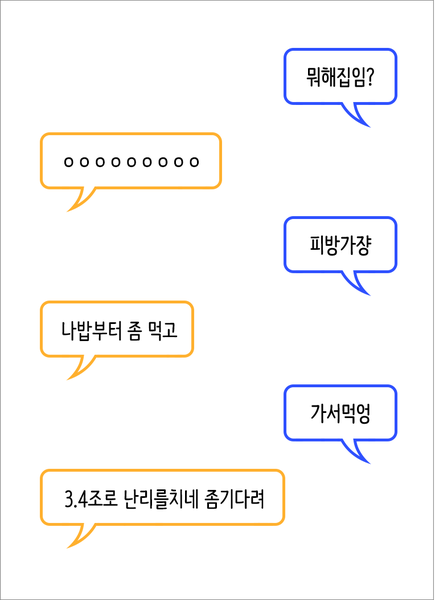

이상적인 데이터의 형태는 이른바 교과서적인 문장들입니다. 앞으로 배워나가겠지만, 우리가 다루게 될 언어 모델(Language Model)이란 바로 단어가 출현하게 될 확률 모델로 이루어져 있습니다. 그러므로 언어 출현 확률의 일정한 패턴을 통계적으로든 딥러닝을 이용해서든 학습시키려면 문법이나 언어 사용 관습의 일정한 패턴을 따른 텍스트 데이터가 이상적입니다.

하지만 위 예시와 같은 채팅 데이터는 띄어쓰기와 맞춤법, 약어 사용 등에서 문제가 많죠. 우리가 사용하는 일상어들은 교과서적인 문장에서 예외적으로 변형될 여지가 무궁무진합니다. 이러한 변형들이 자연어처리 모델 입장에서는 노이즈가 됩니다. 따라서 아직은 소설책이나 신문 기사같이 맞춤법이 비교적 정확하고 노이즈가 적은 데이터를 사용하는 것이 일반적입니다. 혹은 여러 가지 테크닉으로 노이즈를 제거한 후 사용하는 방법이 있죠!

아직은 이라고 표현한 이유는, 위와 같은 데이터들도 양이 무지막지하게 받쳐준다면 모든 변형을 커버할 수 있기 때문입니다. 심지어 교과서만 읽은 인공지능보다 따분하지 않은 언어력을 가질 수 있게 되겠죠! 다만 지금의 인공지능 수준은 서비스 목적에 맞게 데이터를 골라 사용하는 정도기에 아직은 이라는 표현이 적합하다고 봅니다.

그럼 채팅 데이터와 같이 이상적이지 않은 데이터에서 발견할 수 있는 노이즈에는 어떤 유형들이 있을까요?

## 불완전한 문장으로 구성된 대화의 경우

한 문장씩 주고 받는 대화와 달리 메신저는 한 문장을 여러 번에 나눠 전송하거나 여러 문장을 한 번에 전송하는 경우가 있습니다.

예1) A: "아니아니" "오늘이 아니고" "내일이지" / B: "그럼 오늘 사야겠네. 내일 필요하니까?"

## 문장의 길이가 너무 길거나 짧은 경우

아주 짧은 문장은 의미가 없을 수 있고, 대체로 사용빈도가 높은 리액션에 해당하는 경우가 많아서 언어 모델을 왜곡시킬 우려가 있기 때문에 제외해 주는 게 좋습니다.

예1) A: "ㅋㅋㅋ", "ㅠㅠㅠ"

## 아주 긴 문장은 대화와는 관계가 없는 문장일 수 있습니다.

예2) A: "이 편지는 영국에서부터 시작되어…"

## 채팅 데이터에서 문장 시간 간격이 너무 긴 경우

메신저는 누가 자판을 치는지 모르기 때문에 서로의 말이 얽히게 됩니다. 따라서 서로의 말의 텀이 짧으면 그것은 대화가 아니라 서로 할말만 하는 상태일 수 있습니다.

예1) A: "겨울왕국2" / B: "보러가자" / A: "엊그제 봤는데 잼씀" / B: "오늘 저ㄴ 아니 ㅡㅡ"

## 혹은 말의 텀이 너무 길다면 그것은 연속된 대화로 보기 어렵습니다.

예2) A: "나 10만원만 빌려줄 수 있어?" / …… / B: "아 미안 지금 봤다 아직 필요해?"

## 바람직하지 않은 문장의 사용

욕설의 비율이나, 오타의 비율이 높은 문장은 자연어 모델 학습에 사용하지 않는 것이 좋습니다.

어떻습니까? 텍스트 데이터의 특성에 따라 고려해야 할 노이즈의 특성이 무궁무진하지 않나요? 우리가 아직은 이런 특성들을 노이즈로 취급해서 제거하고 싶어 하지만, 사실은 이 노이즈에 내포된 미묘한 느낌의 차이나 특수한 상황 정보들 또한 언젠가는 세밀하게 고려할 수 있을 때가 올 것이라 생각합니다.

## 하지만 지금은 좀 더 단순하고 근본적인 노이즈에 집중하겠습니다. 예를 들면 아래와 같은 문장들이죠.

1. Hi, my name is John. ("Hi," "my", ..., "John." 으로 분리됨) - 문장부호
2. First, open the first chapter. (First와 first를 다른 단어로 인식) - 대소문자
3. He is a ten-year-old boy. (ten-year-old를 한 단어로 인식) - 특수문자
대표적인 세 가지 노이즈 유형입니다. 하나하나 해결하며 완벽한 말뭉치를 만들어봅시다!

노이즈 유형 
## (1) 문장부호 : Hi, my name is john.
먼저 노이즈 유형 (1) 문장부호입니다. 우리는 문장부호를 배웠으니 Hi, 가 Hi 와 , 의 결합인 것을 알지만 컴퓨터는 명시해 주지 않는다면 알파벳에 , 가 포함되어 있다고 생각할 수도 있겠죠? 문장부호를 단어와 분리하면 해결이 되는 상황이기 때문에 문장부호 양쪽에 공백을 추가하는 방법을 취합시다!

In [4]:
def pad_punctuation(sentence, punc):
    for p in punc:
        sentence = sentence.replace(p, " " + p + " ")

    return sentence

sentence = "Hi, my name is john."

print(pad_punctuation(sentence, [".", "?", "!", ","]))

Hi ,  my name is john . 


Python은 replace() 라는 직관적인 함수를 지원해 주기에, 이를 활용하면 풀고자 하는 문제를 쉽게 풀어낼 수 있습니다!

단순히 문장부호 양옆에 공백을 추가해 주는 방식은 문제를 야기할 수도 있습니다. 이를테면 www.semi01sample.com 라는 구절이 문장에 포함되어 있다면 "www . semi01sample . com" 이라는 요상한 모양새로 변형을 시키겠죠. "Mr.Johnson" 이나 "45,756" 같은 경우도 마찬가집니다.

이런 경우는 불가피한 손실로 취급하고 넘어갑니다. 모든 규칙에 대해 변환을 정의해 줄 수는 없기 때문이죠. 게다가 이러한 예외들은 보통 우리가 수행하고자 하는 목적에 큰 영향을 주지 못합니다. "Mr / . / Johnson" 과 "Barack / Hussein / Obama" 는 컴퓨터 입장에서 똑같이 세 단어로 이루어진 이름일 뿐이니까요.

## 노이즈 유형 (2) 대소문자 : First, open the first chapter.   
그다음은 노이즈 유형 (2) 대소문자입니다. 영어에서 발생하는 문제인데, First와 first 는 같은 의미를 갖고 있음에도 컴퓨터는 f와 F를 다르다고 구분 지어 버릴 수 있겠죠. 이를 방지하기 위해 모든 단어를 소문자로 바꾸는 방법을 취하겠습니다.

엄연히 말하면 위 예시에서 First와 first는 부사와 한정사로 구분되어 각각의 용도를 배우면 더 좋을 것 같지만, 앞서 언급했듯이 아직은 이른 접근이랍니다!

In [5]:
sentence = "First, open the first chapter."

print(sentence.lower())

first, open the first chapter.


In [6]:
sentence = "First, open the first chapter."

# Q. sentence의 모든 단어를 대문자로 바꿔보세요.
# 힌트: upper() 함수를 사용해 보세요!
# [[YOUR CODE]]
print(sentence.upper())

FIRST, OPEN THE FIRST CHAPTER.


## 노이즈 유형 (3) 특수문자 : He is a ten-year-old boy.   
마지막인 노이즈 유형 (3) 특수문자입니다. ten-year-old와 seven-year-old, 그 외의 수많은 나이 표현들을 각각의 단어 취급을 해버리는 일이 벌어지겠죠. 그런 불상사를 방지하기 위해 특수문자를 제거하려 합니다. 하지만 무한한 특수문자를 모두 정의하여 제거할 수는 없겠죠? 따라서 우리는 사용할 알파벳과 기호들을 정의해 이를 제외하곤 모두 제거하도록 하겠습니다.

In [7]:
import re

sentence = "He is a ten-year-old boy."
sentence = re.sub("([^a-zA-Z.,?!])", " ", sentence)

print(sentence)

He is a ten year old boy.


re 패키지는 정규표현식 사용을 도와주는 패키지입니다. 정규표현식을 사용하면 어떤 문장을 규칙에 따라 일반화하는 것이 굉장히 편해집니다. 대신 처음 접하는 분들께는 기호들이 다소 난해하게 다가오죠... 이에 대한 자세한 설명이 궁금하시다면 아래 페이지를 방문해보세요!

Python 정규표현식(Regex)
지금까지 배운 모든 것을 종합하여 문장을 정제하는 함수로 정의한 후, 다음으로 넘어가도록 하죠

In [8]:
# From The Project Gutenberg
# (https://www.gutenberg.org/files/2397/2397-h/2397-h.htm)

corpus = \
"""
In the days that followed I learned to spell in this uncomprehending way a great many words, among them pin, hat, cup and a few verbs like sit, stand and walk.
But my teacher had been with me several weeks before I understood that everything has a name.
One day, we walked down the path to the well-house, attracted by the fragrance of the honeysuckle with which it was covered.
Some one was drawing water and my teacher placed my hand under the spout.
As the cool stream gushed over one hand she spelled into the other the word water, first slowly, then rapidly.
I stood still, my whole attention fixed upon the motions of her fingers.
Suddenly I felt a misty consciousness as of something forgotten—a thrill of returning thought; and somehow the mystery of language was revealed to me.
I knew then that "w-a-t-e-r" meant the wonderful cool something that was flowing over my hand.
That living word awakened my soul, gave it light, hope, joy, set it free!
There were barriers still, it is true, but barriers that could in time be swept away.
"""

def cleaning_text(text, punc, regex):
    # 노이즈 유형 (1) 문장부호 공백추가
    for p in punc:
        text = text.replace(p, " " + p + " ")

    # 노이즈 유형 (2), (3) 소문자화 및 특수문자 제거
    text = re.sub(regex, " ", text).lower()

    return text

print(cleaning_text(corpus, [".", ",", "!", "?"], "([^a-zA-Z0-9.,?!\n])"))


in the days that followed i learned to spell in this uncomprehending way a great many words ,  among them pin ,  hat ,  cup and a few verbs like sit ,  stand and walk . 
but my teacher had been with me several weeks before i understood that everything has a name . 
one day ,  we walked down the path to the well house ,  attracted by the fragrance of the honeysuckle with which it was covered . 
some one was drawing water and my teacher placed my hand under the spout . 
as the cool stream gushed over one hand she spelled into the other the word water ,  first slowly ,  then rapidly . 
i stood still ,  my whole attention fixed upon the motions of her fingers . 
suddenly i felt a misty consciousness as of something forgotten a thrill of returning thought  and somehow the mystery of language was revealed to me . 
i knew then that  w a t e r  meant the wonderful cool something that was flowing over my hand . 
that living word awakened my soul ,  gave it light ,  hope ,  joy ,  set it free !

# 3. 분산표현 : 바나나와 사과의 관계를 어떻게 표현할까?  
단어의 희소 표현과 분산 표현
**임베딩 레이어(Embedding Layer)** 를 통해 단어의 **분산 표현(distributed representation)** 을 구현할 수 있는데요. 임베딩 레이어는 자연어 처리 분야에서 거의 기본에 해당하는 요소입니다. 그럼 분산 표현에 대해 알아 보겠습니다.

**분산 표현과 반대되는 표현으로 희소 표현(Sparse representation)** 이라는 것이 있습니다. 어느 표현이든 단어를 벡터로 표현하겠다는 점에서는 동일합니다. 하지만, 단어의 의미를 표현하는 접근 방식에서 큰 차이가 있습니다. 예를 들자면 아래와 같습니다.

사람의 성별을 표현하는 남자와 여자라는 두 단어를 수로 표현하려면 어떻게 하면 될까요? 예컨대 남자: [-1], 여자: [1] 혹은 남자: [1], 여자: [-1] 의 형태로 표현해 볼 수 있겠네요. 전자로 생각을 하도록 하죠.

다음으로 등장한 단어는 소년과 소녀입니다. 두 단어는 각각 어린 남자와 여자를 의미하니, 앞서 생성한 "성별" 이라는 속성에 "나이가 어리다" 라는 속성을 추가해야겠습니다. 즉, 소년: [-1, -1], 소녀: [1, -1] 이 되겠군요! "나이가 많다" 라는 속성을 가진 할아버지, 할머니는 자동적으로 할아버지: [-1, 1], 할머니: [1, 1] 이 되는 것도 알 수 있습니다.

잠깐, 그러면 아저씨와 아줌마는 어떻게 표현하죠..? 아하, 각 속성값들이 정수가 아니라 실수라면 표현이 가능하겠네요! 1차적으로 완성된 우리의 희소 표현 방식의 단어 사전은 아래와 같습니다.

In [12]:
# {
#          [성별, 연령]
#     남자: [-1.0, 0.0], // 이를테면 0.0 이 "관계없음 또는 중립적" 을 의미할 수 있겠죠!
#     여자: [1.0, 0.0],
#     소년: [-1.0, -0.7],
#     소녀: [1.0, -0.7],
#     할머니: [1.0, 0.7],
#     할아버지: [-1.0, 0.7],
#     아저씨: [-1.0, 0.2],
#     아줌마: [1.0, 0.2]
# }

지금 우리가 한 것이 바로 **희소 표현(Sparse representation)** 입니다. 단어를 고차원 벡터로 변환하는 것이죠. 사람을 나이와 성별로 구분하기 위해선 **적어도 2차원이 필요함** 을 배웠네요! 2차원이라 뭐가 고차원인지, 뭐가 희소하다는 건지 느낌이 안 오시나요? 그럼 좀 더 진행해 볼까요?

위 예시는 모든 단어들이 "사람"이라는 속성을 가짐 을 전제하죠? 하지만 세상엔 바나나도 있고 사과도 있답니다. "과일인지 아닌지 판단"하는 속성을 추가하고, "색깔" 속성을 추가해서 이번엔 바나나와 사과를 구분해보죠!

In [13]:
# {
#     //      [성별, 연령, 과일, 색깔]
#     남자: [-1.0, 0.0, 0.0, 0.0],
#     여자: [1.0, 0.0, 0.0, 0.0],
#     사과: [0.0, 0.0, 1.0, 0.5],   // 빨갛게 잘 익은 사과
#     바나나: [0.0, 0.0, 1.0, -0.5] // 노랗게 잘 익은 바나나
# }

어떤가요? 속성의 종류가 늘어나고 워드 벡터의 차원이 따라서 늘어나기 시작하니까 벡터에서 0.0이 자주 나오기 시작하는 것이 보이시나요? 4차원까지는 우리의 직관으로 늘려보았지만, 우리가 이런 방식으로 세상의 모든 단어의 속성을 규명해서 표현하려면 과연 몇 차원의 벡터가 필요할까요? 이번 생에는 어려울지도 모르겠네요. 엄청난 고차원의 벡터를 이런 방식으로 만들어낸다 한들, 워드 벡터의 대부분의 차원은 0.0으로 채워진 희소 표현이 만들어질 것입니다.

이런 방식의 문제가 무엇일까요? 너무 고차원이 필요하고 불필요한 메모리와 연산량이 낭비된다는 점 말고도 중요한 문제점 하나는, 희소 표현의 워드 벡터끼리는 단어들 간의 의미적 유사도를 계산할 수 없다는 점입니다.

두 고차원 벡터의 유사도는 코사인 유사도(Cosine Similarity) 를 통해 구할 수 있습니다. 자세한 내용이 궁금하다면 아래 웹페이지를 확인하세요!

In [16]:
import numpy as np
from numpy import dot
from numpy.linalg import norm

def cos_sim(A, B):
  return dot(A, B)/(norm(A)*norm(B))

doc1 = np.array([-1.0,0,0,0])
doc2 = np.array([0,0,1.0,0.5])

print('문서 1과 문서2의 유사도 :',cos_sim(doc1, doc2))

#공유하는 의미속성이 없는 위 두 벡터의 내적은 0이 되므로, 코사인 유사도도 역시 0이 됩니다. 이렇게 되면 희소표현으로 본 두 단어 사이에는 아무런 의미적 유사도가 없게 됩니다.


문서 1과 문서2의 유사도 : 0.0


그래서 우린 Embedding 레이어를 사용해 각 단어가 몇 차원의 속성을 가질지 정의하는 방식으로 단어의 **분산 표현(distributed representation)** 를 구현하는 방식을 주로 사용하게 됩니다. 만약 10,000개의 단어를 256차원의 속성으로 표현하고 싶다면 Embedding 레이어는 아래와 같이 정의되겠죠.

In [18]:
#embedding_layer = torch.nn.Embedding(num_embeddings=10000, embedding_dim=256)

위 단어의 분산 표현에는 우리가 일일이 정의할 수 없는 어떤 추상적인 속성들이 256차원 안에 골고루 분산되어 표현됩니다. 희소 표현처럼 속성값을 임의로 지정해 주는 것이 아니라, 수많은 텍스트 데이터를 읽어가며 적합한 값을 찾아갈 것입니다. 적절히 훈련된 분산 표현 모델을 통해 우리는 단어 간의 의미 유사도를 계산하거나, 이를 feature로 삼아 복잡한 자연어처리 모델을 훈련시킬 수 있게 됩니다.

이에 대한 방법은 후술하도록 하죠!

단어 사전 구성과 활용의 문제
하지만 여기서 짚고 넘어가야 할 점이 있습니다. 위에서 Embedding 레이어를 사용해 구현한 분산 표현은 컴퓨터 입장에서는 단어 사전이 될 것입니다. 그런데 만약 사전만 가지고 외국에 나가면 바로 그 나라 말을 알아듣고 해석할 수 있을까요? 아마 단어 단위로 명확하게 끊어서 들리지조차 않을 것이기 때문에 단어 사전이 있다 한들 아무런 소용이 없게 되지 않을까요?

컴퓨터한테도 비슷한 일이 벌어지곤 합니다. 우리는 마치 문장이 단어 단위로 명확하게 쪼개져 있어서, 컴퓨터가 각 단어에 해당하는 분산 표현을 언제든 정확히 찾을 수 있을 것처럼 전제하고 위와 같은 컴퓨터용 단어 사전을 구축해 두었지만, 정작 컴퓨터는 전혀 엉뚱한 단어로 해석하거나 혹은 사전에서 그 단어를 찾지 못해 당황하는 일이 생기게 됩니다. 그것은 바로 컴퓨터가 문장을 단어 단위로 정확하게 끊어 읽지 못하기 때문에 벌어지는 일입니다. 다음 스텝에서 이 문제의 어려움을 좀 더 자세하게 다루어 봅시다.

# 4. 토큰화 : 그녀는? 그녀+는?
한 문장에서 단어의 수는 어떻게 정의할 수 있을까요? "그녀는 나와 밥을 먹는다" 라는 문장이 주어지면 공백 기준으로 나누어 1: 그녀는 2: 나와 3: 밥을 4: 먹는다 4개 단어로 이루어졌다고 단정 지을 수 있을까요? 어쩌면 1: 그녀 2: 는 3: 나 4: 와 5: 밥 6: 을 7: 먹는다 처럼 잘게 잘게 쪼개어 7개 단어로 이루어졌다고 할 수도 있겠죠? 그것은 **우리가 정의할 토큰화 기법이 결정할 부분**이랍니다!

문장을 어떤 기준으로 쪼개었을 때, **쪼개진 각 단어들을 토큰(Token) 이라고 부릅니다. 그리고 그 쪼개진 기준이 토큰화(Tokenization) 기법에 의해 정해지죠. 이번 스텝에서는 토큰화의 여러 가지 기법에 대해 배워보도록 하겠습니다.**

## 공백 기반 토큰화
자연어의 노이즈를 제거하는 방법 중 하나로 우리는 Hi, 를 Hi와 ,로 나누기 위해 문장부호 양옆에 공백을 추가해 주었습니다. 그것은 이 공백 기반 토큰화를 사용하기 위해서였죠! 당시의 예제 코드를 다시 가져와 공백을 기반으로 토큰화를 진행해 보겠습니다.

In [19]:
corpus = \
"""
in the days that followed i learned to spell in this uncomprehending way a great many words ,  among them pin ,  hat ,  cup and a few verbs like sit ,  stand and walk .
but my teacher had been with me several weeks before i understood that everything has a name .
one day ,  we walked down the path to the well house ,  attracted by the fragrance of the honeysuckle with which it was covered .
some one was drawing water and my teacher placed my hand under the spout .
as the cool stream gushed over one hand she spelled into the other the word water ,  first slowly ,  then rapidly .
i stood still ,  my whole attention fixed upon the motions of her fingers .
suddenly i felt a misty consciousness as of something forgotten a thrill of returning thought  and somehow the mystery of language was revealed to me .
i knew then that  w a t e r  meant the wonderful cool something that was flowing over my hand .
that living word awakened my soul ,  gave it light ,  hope ,  joy ,  set it free !
there were barriers still ,  it is true ,  but barriers that could in time be swept away .
"""

tokens = corpus.split()

print("문장이 포함하는 Tokens:", tokens)

문장이 포함하는 Tokens: ['in', 'the', 'days', 'that', 'followed', 'i', 'learned', 'to', 'spell', 'in', 'this', 'uncomprehending', 'way', 'a', 'great', 'many', 'words', ',', 'among', 'them', 'pin', ',', 'hat', ',', 'cup', 'and', 'a', 'few', 'verbs', 'like', 'sit', ',', 'stand', 'and', 'walk', '.', 'but', 'my', 'teacher', 'had', 'been', 'with', 'me', 'several', 'weeks', 'before', 'i', 'understood', 'that', 'everything', 'has', 'a', 'name', '.', 'one', 'day', ',', 'we', 'walked', 'down', 'the', 'path', 'to', 'the', 'well', 'house', ',', 'attracted', 'by', 'the', 'fragrance', 'of', 'the', 'honeysuckle', 'with', 'which', 'it', 'was', 'covered', '.', 'some', 'one', 'was', 'drawing', 'water', 'and', 'my', 'teacher', 'placed', 'my', 'hand', 'under', 'the', 'spout', '.', 'as', 'the', 'cool', 'stream', 'gushed', 'over', 'one', 'hand', 'she', 'spelled', 'into', 'the', 'other', 'the', 'word', 'water', ',', 'first', 'slowly', ',', 'then', 'rapidly', '.', 'i', 'stood', 'still', ',', 'my', 'whole', 'attenti

첫 번째로 배우는 가장 간단한 토큰화 기법이니만큼 사용법도 아주 간단합니다. split() 함수를 호출하기만 하면 자동으로 토큰들의 List로 만들어주죠.

단어 사전에 위 단어들이 전부 등재되어 있다면야 썩 나쁘지 않겠죠? 사실상 같은 단어인 days 와 day 가 구분되어 따로 저장이 되는 정도의 문제는 있겠지만, s 를 모두 한 칸 띌 수도 없는 노릇이기에 불가피한 손실로 취급합니다(후에 등장할 방법에서 해결될 문제입니다!).

## 형태소 기반 토큰화
하지만 우리에겐 영어 문장이 아닌 한국어 문장을 처리할 일이 더 많을 것이고, 한국어 문장은 공백 기준으로 토큰화를 했다간 엉망진창의 단어들이 등장하는 것을 알 수 있습니다. 문장부호처럼 "은 / 는 / 이 / 가" 양옆에 공백을 붙이자구요? 글쎄요... 가로 시작하는 단어만 해도 가면, 가위, 가족, 가수... 의도치 않은 변형이 너무나도 많이 일어날 것 같네요!

이를 어떻게 해결할 수 있을까요? 정답은 형태소에 있습니다. 어릴 적 국어 시간에 배운 기억이 새록새록 나시나요? 상기시켜드리면 형태소의 정의는 아래와 같습니다.

(명사) 뜻을 가진 가장 작은 말의 단위.

예를 들어, 오늘도 공부만 한다 라는 문장이 있다면, 오늘, 도, 공부, 만, 한다 로 쪼개지는 것이 바로 형태소죠. 한국어는 이를 활용해 토큰화를 할 수 있습니다!

한국어 형태소 분석기는 대표적으로 KoNLPy가 사용됩니다.

KoNLPy: 파이썬 한국어 NLP - KoNLPy 0.5.2 documentation
KoNLPy는 내부적으로 5가지의 형태소 분석 Class를 포함하고 있습니다 천하무적인 것은 (아직은) 없으니, 각 분석기를 직접 테스트해보고 적합한 것을 선택해 사용하면 됩니다.

아래 웹페이지에서 그 실험을 대신해 주었네요. 정말 좋은 참고 자료입니다!

한국어 형태소 분석기 성능 비교
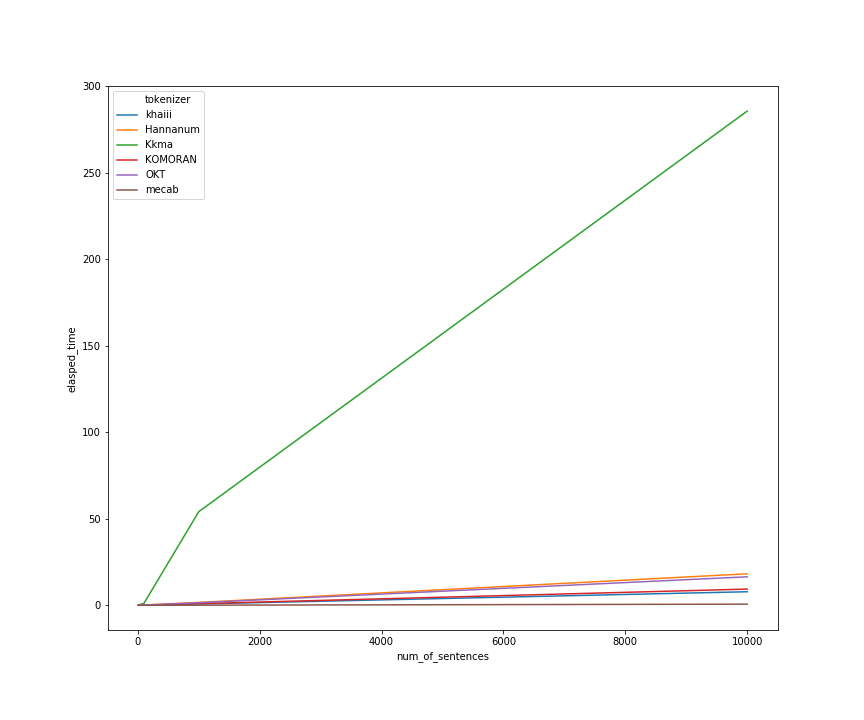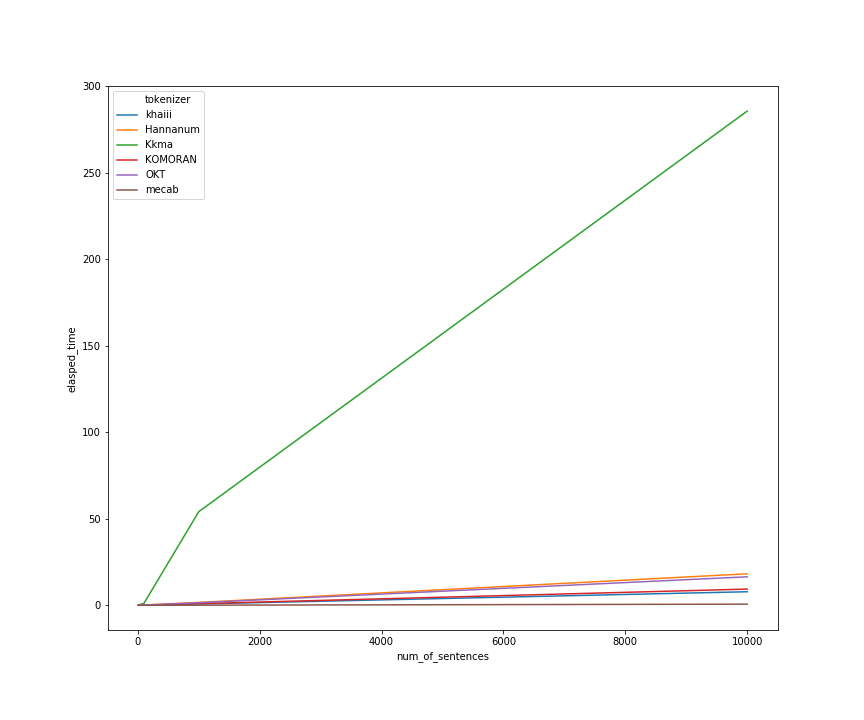
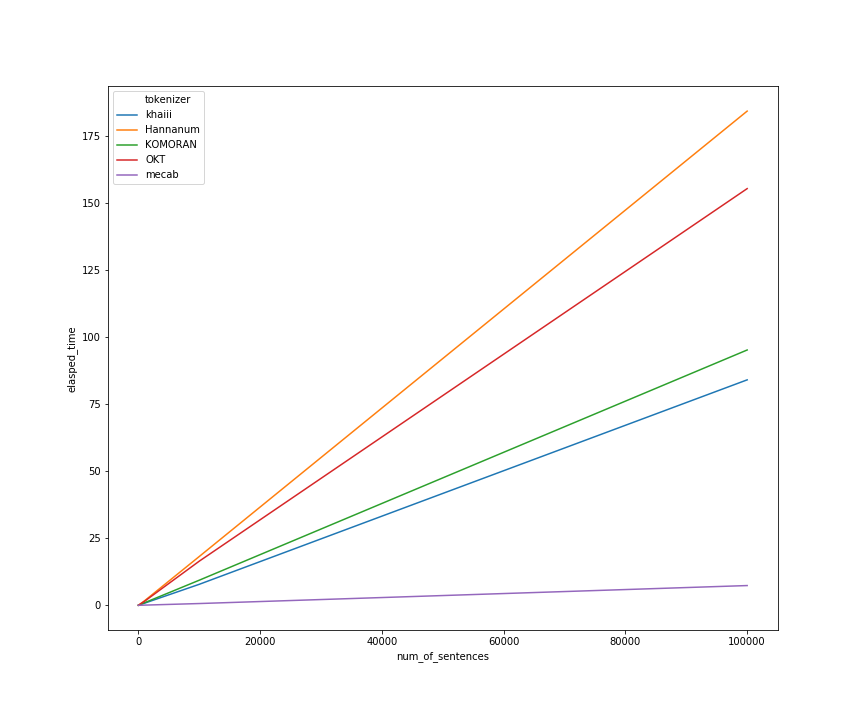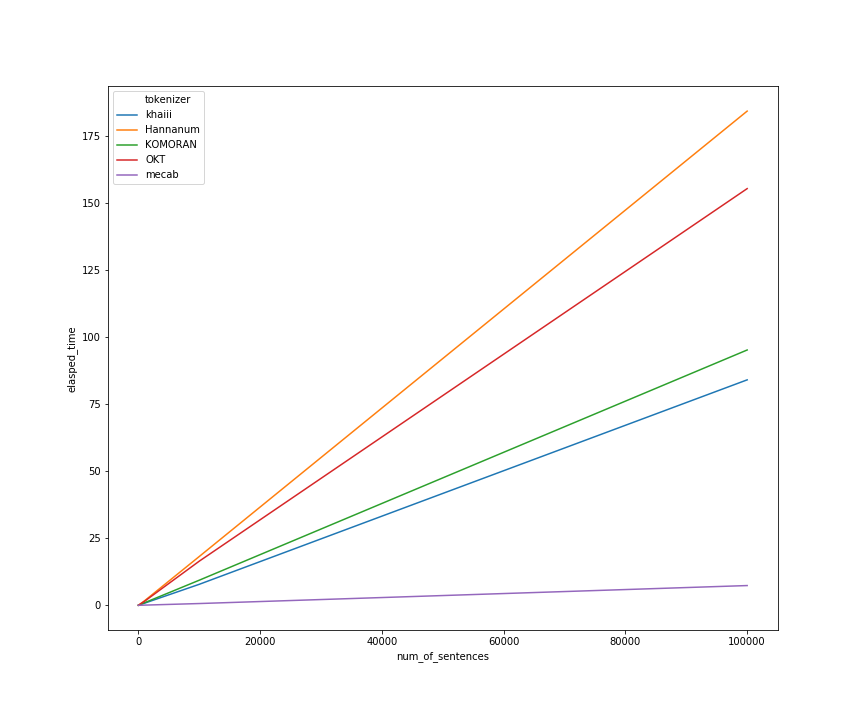

빠른속도 적당한 품질 mecab
가장 좋은 품질 KOMORAN 

In [1]:
from konlpy.tag import Hannanum,Kkma,Komoran,Mecab,Okt

In [2]:
from konlpy.tag import Mecab
mecab = Mecab()
print(mecab.morphs("테스트 문장입니다."))

# $ pip install konlpy
# $ cd ~/work/text_preprocess
# $ git clone https://github.com/SOMJANG/Mecab-ko-for-Google-Colab.git
# $ cd Mecab-ko-for-Google-Colab
# $ bash install_mecab-ko_on_colab190912.sh
#sudo apt install default-jre

['테스트', '문장', '입니다', '.']


In [3]:
tokenizer_list = [Hannanum(),Kkma(),Komoran(),Mecab(),Okt()]

kor_text = '코로나바이러스는 2019년 12월 중국 우한에서 처음 발생한 뒤 전 세계로 확산된, 새로운 유형의 호흡기 감염 질환입니다.'

for tokenizer in tokenizer_list:
    print('[{}] \n{}'.format(tokenizer.__class__.__name__, tokenizer.pos(kor_text)))

[Hannanum] 
[('코로나바이러스', 'N'), ('는', 'J'), ('2019년', 'N'), ('12월', 'N'), ('중국', 'N'), ('우한', 'N'), ('에서', 'J'), ('처음', 'M'), ('발생', 'N'), ('하', 'X'), ('ㄴ', 'E'), ('뒤', 'N'), ('전', 'N'), ('세계', 'N'), ('로', 'J'), ('확산', 'N'), ('되', 'X'), ('ㄴ', 'E'), (',', 'S'), ('새롭', 'P'), ('은', 'E'), ('유형', 'N'), ('의', 'J'), ('호흡기', 'N'), ('감염', 'N'), ('질환', 'N'), ('이', 'J'), ('ㅂ니다', 'E'), ('.', 'S')]
[Kkma] 
[('코로나', 'NNG'), ('바', 'NNG'), ('이러', 'MAG'), ('슬', 'VV'), ('는', 'ETD'), ('2019', 'NR'), ('년', 'NNM'), ('12', 'NR'), ('월', 'NNM'), ('중국', 'NNG'), ('우', 'NNG'), ('하', 'XSV'), ('ㄴ', 'ETD'), ('에', 'VV'), ('서', 'ECD'), ('처음', 'NNG'), ('발생', 'NNG'), ('하', 'XSV'), ('ㄴ', 'ETD'), ('뒤', 'NNG'), ('전', 'NNG'), ('세계', 'NNG'), ('로', 'JKM'), ('확산', 'NNG'), ('되', 'XSV'), ('ㄴ', 'ETD'), (',', 'SP'), ('새', 'NNG'), ('롭', 'XSA'), ('ㄴ', 'ETD'), ('유형', 'NNG'), ('의', 'JKG'), ('호흡기', 'NNG'), ('감염', 'NNG'), ('질환', 'NNG'), ('이', 'VCP'), ('ㅂ니다', 'EFN'), ('.', 'SF')]
[Komoran] 
[('코로나바이러스', 'NNP'), ('는', 'JX'), ('2019', 'SN'

어떤가요? 완벽한 토크나이저는 역시 존재하지 않는 것 같습니다. 저마다 장단점이 존재하는데, 문장을 바꿔 가며 토크나이저마다의 장단점을 정리해 보는 것도 좋은 경험이 될 것입니다.

## 사전에 없는 단어의 문제
지금까지 배운 공백 기반이나, 형태소 기반의 토큰화 기법들은 모두 의미를 가지는 단위로 토큰을 생성합니다. 이 기법의 경우, 데이터에 포함되는 모든 단어를 처리할 수는 없기 때문에 자주 등장한 상위 N개의 단어만 사용하고 나머지는 <unk>같은 특수한 토큰(Unknown Token)으로 치환해버립니다. 자원이 무한하고 데이터도 무한하다면 그러지 않아도 되겠지만... 모든 것은 한정되어 있기 때문에 이 또한 불가피한 손실이죠. 하지만 이것은 종종 큰 문제를 야기합니다.



만약 위 문장을 영문으로 번역해야 한다면 어떨까요? 핵심인 단어 코로나바이러스와 우한을 모른다면 제대로 해낼 수 있을 리가 없습니다. 이를 OOV(Out-Of-Vocabulary) 문제라고 합니다. 이처럼 새로 등장한(본 적 없는) 단어에 대해 약한 모습을 보일 수밖에 없는 기법들이기에, 이를 해결하고자 하는 시도들이 있었습니다. 그리고 그것이 우리가 다음 스텝에서 배울, Wordpiece Model이죠!

# 5. 토큰화 : 다른 방법들
Wordpiece Model(WPM) 은 우리가 접한 적이 있는 아이디어를 기반으로 만들어졌습니다. 두 단어 preview와 predict를 보면 접두어인 pre가 공통되고 있죠? pre가 들어간 단어는 주로 "미리", "이전의" 와 연계되는 의미를 가지고 있습니다. 컴퓨터도 두 단어를 따로 볼 게 아니라 pre+view와 pre+dict로 본다면 학습을 더 잘 할 수 있지 않을까요?

이처럼 한 단어를 여러 개의 Subword의 집합으로 보는 방법이 WPM입니다. WPM의 원리를 알기 전, 먼저 알아야 할 것이 바로 Byte Pair Encoding(BPE) 입니다.

## Byte Pair Encoding(BPE)
BPE 알고리즘이 고안된 것은 1994년입니다. 그때는 자연어 처리에 적용하기 위해서가 아니라 데이터 압축을 위해서 생겨났었죠. 데이터에서 가장 많이 등장하는 바이트 쌍(Byte Pair) 을 새로운 단어로 치환하여 압축하는 작업을 반복하는 방식으로 동작합니다. 예시는 아래와 같습니다.

In [4]:
# aaabdaaabac # 가장 많이 등장한 바이트 쌍 "aa"를 "Z"로 치환합니다.
# →
# ZabdZabac   # "aa" 총 두 개가 치환되어 4바이트를 2바이트로 압축하였습니다.
# Z=aa        # 그다음 많이 등장한 바이트 쌍 "ab"를 "Y"로 치환합니다.
# →
# ZYdZYac     # "ab" 총 두 개가 치환되어 4바이트를 2바이트로 압축하였습니다.
# Z=aa        # 여기서 작업을 멈추어도 되지만, 치환된 바이트에 대해서도 진행한다면
# Y=ab        # 가장 많이 등장한 바이트 쌍 "ZY"를 "X"로 치환합니다.
# →
# XdXac
# Z=aa
# Y=ab
# X=ZY       # 압축이 완료되었습니다!

아주 직관적인 알고리즘이죠? 이를 토큰화에 적용하자고 제안한 것은 2015년이었습니다. 모든 단어를 문자(바이트)들의 집합으로 취급하여 자주 등장하는 문자 쌍을 합치면, 접두어나 접미어의 의미를 캐치할 수 있고, 처음 등장하는 단어는 문자(알파벳)들의 조합으로 나타내어 OOV 문제를 완전히 해결할 수 있다는 것이죠!

비교적 최근의 기술을 소개해드리는 만큼 논문을 함께 첨부합니다.

Neural Machine Translation of Rare Words with Subword Units
위 논문은 Python 소스 코드를 함께 제공해 주어 간편하게 실습을 해 볼 수 있습니다. 논문에서 제공해 주는 예제로 동작 방식을 자세히 들여다보죠!

In [5]:
import re, collections

# 임의의 데이터에 포함된 단어들입니다.
# 우측의 정수는 임의의 데이터에 해당 단어가 포함된 빈도수입니다.
vocab = {
    'l o w '      : 5,
    'l o w e r '  : 2,
    'n e w e s t ': 6,
    'w i d e s t ': 3
}

num_merges = 5

def get_stats(vocab):
    """
    단어 사전을 불러와
    단어는 공백 단위로 쪼개어 문자 list를 만들고
    빈도수와 쌍을 이루게 합니다. (symbols)
    """
    pairs = collections.defaultdict(int)

    for word, freq in vocab.items():
        symbols = word.split()

        for i in range(len(symbols) - 1):             # 모든 symbols를 확인하여
            pairs[symbols[i], symbols[i + 1]] += freq  # 문자 쌍의 빈도수를 저장합니다.

    return pairs

def merge_vocab(pair, v_in):
    """
    문자 쌍(pair)과 단어 리스트(v_in)를 입력받아
    각각의 단어에서 등장하는 문자 쌍을 치환합니다.
    (하나의 글자처럼 취급)
    """
    v_out = {}
    bigram = re.escape(' '.join(pair))
    p = re.compile(r'(?<!\S)' + bigram + r'(?!\S)')

    for word in v_in:
        w_out = p.sub(''.join(pair), word)
        v_out[w_out] = v_in[word]

    return v_out, pair[0] + pair[1]

token_vocab = []

for i in range(num_merges):
    print(">> Step {0}".format(i + 1))

    pairs = get_stats(vocab)
    best = max(pairs, key=pairs.get)  # 가장 많은 빈도수를 가진 문자 쌍을 반환합니다.
    vocab, merge_tok = merge_vocab(best, vocab)
    print("다음 문자 쌍을 치환:", merge_tok)
    print("변환된 Vocab:\n", vocab, "\n")

    token_vocab.append(merge_tok)

print("Merged Vocab:", token_vocab)

>> Step 1
다음 문자 쌍을 치환: es
변환된 Vocab:
 {'l o w ': 5, 'l o w e r ': 2, 'n e w es t ': 6, 'w i d es t ': 3} 

>> Step 2
다음 문자 쌍을 치환: est
변환된 Vocab:
 {'l o w ': 5, 'l o w e r ': 2, 'n e w est ': 6, 'w i d est ': 3} 

>> Step 3
다음 문자 쌍을 치환: lo
변환된 Vocab:
 {'lo w ': 5, 'lo w e r ': 2, 'n e w est ': 6, 'w i d est ': 3} 

>> Step 4
다음 문자 쌍을 치환: low
변환된 Vocab:
 {'low ': 5, 'low e r ': 2, 'n e w est ': 6, 'w i d est ': 3} 

>> Step 5
다음 문자 쌍을 치환: ne
변환된 Vocab:
 {'low ': 5, 'low e r ': 2, 'ne w est ': 6, 'w i d est ': 3} 

Merged Vocab: ['es', 'est', 'lo', 'low', 'ne']


만일 lowest라는 처음 보는 단어가 등장하더라도, 위 알고리즘을 따르면 어느 정도 의미가 파악된 low와 est의 결합으로 표현할 수 있습니다. 또 BPE의 놀라운 점은 아무리 큰 데이터도 원하는 크기로 OOV 문제없이 사전을 정의할 수 있다는 것입니다. 극단적으로 생각했을 때 알파벳 26개와 특수문자, 문장부호를 아무리 추가해도 100개 이내로 사전을 정의할 수 있죠.(물론 그러면 안 됩니다!!)

Embedding 레이어는 단어의 개수 x Embedding 차원 수 의 Weight를 생성하기 때문에 단어의 개수가 줄어드는 것은 곧 메모리의 절약으로 이어집니다. 많은 데이터가 곧 정확도로 이어지기 때문에 이런 기여는 굉장히 의미가 있습니다!

하지만 아직도! 완벽하다고는 할 수 없습니다. 만약 수많은 데이터를 사용해 만든 BPE 사전으로 모델을 학습시키고 문장을 생성하게 했다고 합시다. 그게 [i, am, a, b, o, y, a, n, d, you, are, a, gir, l]이라면, 어떤 기준으로 이들을 결합해서 문장을 복원하죠? 몽땅 한꺼번에 합쳤다간 끔찍한 일이 벌어질 것만 같습니다...

## Wordpiece Model(WPM)
이에 구글에서 BPE를 변형해 제안한 알고리즘이 바로 WPM입니다. WPM은 BPE에 대해 두 가지 차별성을 가집니다.

공백 복원을 위해 단어의 시작 부분에 언더바 _ 를 추가합니다.
빈도수 기반이 아닌 가능도(Likelihood)를 증가시키는 방향으로 문자 쌍을 합칩니다. (더 '그럴듯한' 토큰을 만들어냅니다.)
첫 번째 문항은 아주 쉬운 내용으로, 앞서 사용한 예문을 빌리면 [_i, _am, _a, _b, o, y, _a, n, d, _you, _are, _a, _gir, l]로 토큰화를 한다는 것입니다. 이렇게 하면 문장을 복원하는 과정이 
1) 모든 토큰을 합친 후,
2) 2) 언더바 _를 공백으로 치환으로 마무리되어 간편하죠.

두 번째 문항은 다소 난해하게 다가올 수도 있습니다. 직관적인 이해를 얻고 넘어가는 것을 목표로 하죠. 본 내용은 아래 논문 3절과 4절에 자세하게 나와 있습니다.

JAPANESE AND KOREAN VOICE SEARCH
(여기서 잠깐) 구글에서 이 기법을 한국어, 일본어 텍스트 처리를 위해 고려했다는 사실이 흥미롭지 않나요? 이 점은 2가지를 시사합니다.

조사, 어미 등의 활용이 많고 복잡한 한국어 같은 모델의 토크나이저로 WPM이 좋은 대안이 될 수 있다.

WPM은 어떤 언어든 무관하게 적용 가능한 language-neutral하고 general한 기법이다. 한국어 형태소 분석기처럼 한국어에만 적용 가능한 기법보다 훨씬 활용도가 크다.

그리고 가능도에 대한 개념이 낯설다면 아래 웹페이지를 방문해보시길 권장합니다.

확률 vs 가능도
저자들은 Katz's Back-off Model 을 통해 토큰화된 사전으로부터 결합할 단어를 선정합니다. Katz's Back-off Model 은 LM에서 등장하지 않은 단어에 대해 확률을 할당할 수 있는 모델입니다. 흔히 사용되는 개념은 아니므로 "그런 게 있구나~" 하고 알아만 두시면 좋습니다. 수식을 아래에 첨부하지만 이해하지 않으셔도 괜찮습니다!
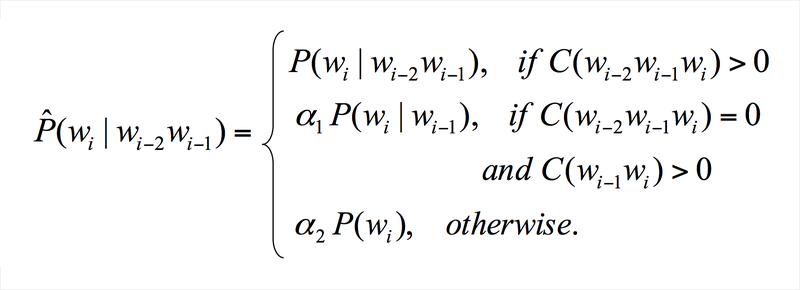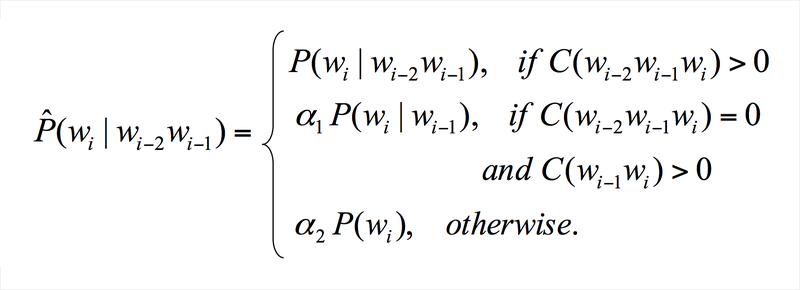

토큰화의 끝판왕으로 보이는 이 WPM은 아쉽게도 공개되어 있지는 않습니다. 대신에 구글의 SentencePiece 라이브러리를 통해 고성능의 BPE를 사용할 수 있습니다! SentencePiece에는 전처리 과정도 포함되어 있어서, 데이터를 따로 정제할 필요가 없어 간편하기까지 합니다.

google/sentencepiece
이제 우리는 어떤 언어에도 OOV 발생 우려 없이 안정적으로 활용할 수 있는 멋진 토크나이징 기술을 확보했습니다. 이제는 컴퓨터가 단어사전을 안심하고 활용할 수 있겠군요!


## soynlp
이외에도 한국어를 위한 토크나이저로 soynlp를 활용할 수 있습니다. soynlp는 한국어 자연어 처리를 위한 라이브러리인데요. 토크나이저 외에도 단어 추출, 품사 판별, 전처리 기능도 제공합니다.

soynlp
형태소 기반의 토크나이저가 미등록 단어에 취약하기 때문에 WordPiece Model을 사용하는 것처럼, 형태소 기반인 koNLPy의 단점을 해결하기 위해 soynlp를 사용할 수 있습니다.

soynlp의 토크나이저는 '학습데이터를 이용하지 않으면서 데이터에 존재하는 단어를 찾거나, 문장을 단어열로 분해, 혹은 품사 판별을 할 수 있는 비지도학습 접근법을 지향합니다' 라고 밝히고 있는데요.

문장에서 처음 단어를 받아들일 때 단어의 경계를 알아야 올바르게 토큰화를 할 수 있습니다. 이때 단어의 경계를 비지도학습을 통해 결정하겠다는 말이에요. 비지도학습을 통한 방법이기 때문에 미등록 단어도 토큰화가 가능합니다. 여기서 비지도학습을 가능케 하는 것이 통계적인 방법이라서 soynlp를 통계 기반 토크나이저로 분류하기도 합니다.

트와이스가 한 단어임을 인지하기 위해서 트, 트와, 트와이, 트와이스 각각 다음 글자의 확률을 계산해서 비교한다고 생각하면 좋습니다. 수학적으로 자세한 내용은 여기서는 다루지 않습니다. 다만 koNLPy외에도 soynlp가 있다는 점을 기억해 주세요.

## 그럼에도...
이렇게 토큰화 방법을 알아 보았지만 이걸 가지고 단어의 분산 표현을 얻는 법을 제대로 다루지는 않았습니다. 이쯤에서 이런 고민이 생기게 됩니다. 한국어라면 자동차를 _자동 / 차 로 분리되는데... 속성이 아무리 추상적이래도 보기에 차가 마시는 차인지, 달리는 차인지 도통 알 수가 없죠? 게다가 설령 토큰화가 완벽하다고 해도, 남자가 [-1, 0]인지 [1, 0]인지는 컴퓨터 입장에서는 알 도리가 없습니다.

Embedding 레이어는 선언 즉시 랜덤한 실수로 Weight 값을 채우고, 학습을 진행하며 적당히 튜닝해가는 방식으로 속성을 맞춰가지만 이는 뭔가 찜찜합니다. 토큰들이 멋지게 의미를 갖게 하는 방법은 없을까요?

# 6. 토큰에게 의미를 부여하기
각 토큰들이 랜덤하게 부여된 실수로 살아가지 않게, 그들끼리 유사도 연산을 할 수 있게 의미를 부여하는 알고리즘, 당연히 있습니다! 심지어 토큰화 기법보다 더 많이요! 대표적인 3가지만 알아보도록 하겠습니다. 이번 코스에선 간단하게 아이디어만 이해해도 충분합니다.

## Word2Vec
Word2Vec은 "단어를 벡터로 만든다"는 멋진 이름을 가지고 있습니다. 난 오늘 술을 한 잔 마셨어 라는 문장의 각 단어 즉, 동시에 등장하는 단어끼리는 연관성이 있다는 아이디어로 시작된 알고리즘입니다. 예문의 경우 다른 단어는 몰라도 술과 마셨어는 괜찮은 연관성을 캐치해낼 수 있겠네요.

Word2Vec에 대한 좋은 자료를 읽어보시고, 다시 얘기해보도록 하죠!

위키독스/Word2Vec
1. 희소 표현(Sparse Representation)
2. 분산 표현(Distributed Representation)

학습 속도는 CBOW가 빠르지만, 말뭉치(Corpus)가 커질수록 단어 간의 의미적 유사도나 희귀 단어의 특징을 잡아내는 전반적인 임베딩 품질(성능)은 Skip-gram이 더 뛰어납니다. 그래서 실무에서도 Skip-gram 방식을 더 널리 사용합니다.

## FastText
Word2Vec은 정말 좋은 방법이지만, 연산의 빈부격차가 존재했습니다. 자주 등장하지 않는 단어는 최악의 경우 단 한 번의 연산만을 거쳐 랜덤하게 초기화된 값과 크게 다르지 않은 상태로 알고리즘이 종료될 수 있습니다. FastText는 이를 해결하기 위해 BPE와 비슷한 아이디어를 적용했습니다.

자세한 내용은 아래 웹페이지에서 만나보세요! 글 말미의 Fasttext의 등장 (2016) 파트를 읽으시면 됩니다.

한국어를 위한 어휘 임베딩의 개발 -1-

## ELMo - the 1st Contextualized Word Embedding
위에 소개했던 Word Embedding 알고리즘들은 (역시나) 정말 훌륭하지만, 여전히 고질적인 문제점이 있습니다. 바로 고정적이라는 겁니다! 무슨 말이냐면, 동음이의어를 처리할 수 없다는 얘기입니다.

탐스럽고 먹음직스러웠던 사과가 이렇게 썩어버리다니 너무 아쉽네요.
당신이 저지른 실수는 사과한다고 용서될 수 있는게 아닙니다.
우리는 이 두 문장에 나오는 '사과'의 의미가 다르다는 것을 알고 있습니다. 그러나 Word2Vec이든 FastText이든 간에 이 두 문장에 나오는 사과의 워드 벡터값은 동일할 수밖에 없습니다.

분명 의미가 다른 두 '사과'의 의미를 명확하게 해석하려면 우리에게 무엇이 필요할까요? 네, 서론에서 우리는 그 답을 미리 살펴보았습니다. Context-sensitive Grammar를 따르는 자연어를 이해하려면 문맥(context)의 활용이 필수적입니다.
여기서 '사과'의 context가 되는 것은 무엇일까요? 첫 문장이라면 탐스럽고 먹음직스러운 이 될 것이고 다음 문장이라면 이렇게 썩어버리다니 가 될 것입니다. 즉, 단어의 의미 벡터를 구하기 위해서는 그 단어가 사용된 주변 단어의 맥락을 넘어서 사용된 시퀀스 전체의 맥락이 함께 고려되는 Word Embedding이 필요한 것입니다. 이런 개념을 Contextualized Word Embedding이라고 합니다.

2018년 NLP계에 큰 폭풍을 몰고 왔던 ELMo라는 모델은 데이터에 단어가 등장한 순간, 그 주변 단어 정보를 사용해 Embedding을 구축하는 개념을 처음 소개하면서 자연어처리의 획기적인 발전의 계기를 마련해 준 첫 번째 Contextualized Word Embedding 모델입니다. 정말 멋진 아이디어에요! 아래 웹페이지를 방문해 편안하게 글을 읽어보시길 바랍니다.

전이 학습 기반 NLP (1): ELMo
ELMo

ELMo 는 단어 표현의 두 가지 과제를 직접적으로 해결합니다. 사전 학습된 단어 표현은 복잡한 단어 사용 특성 (예: 구문 및 의미론)과 이러한 사용이 언어적 맥락에 따라 어떻게 달라지는지를 모델링 (즉, 다의어를 모델링) 하는 과제입니다.

ELMo 는 기존 모델에 쉽게 통합될 수 있으며, 다양한 어려운 언어 이해 문제에서 모든 경우에서 최첨단 성능을 크게 향상시키는 새로운 유형의 심층적 맥락화된 단어 표현입니다.

ELMo 표현은 각 토큰이 전체 입력 문장의 함수인 표현을 할당받는 점에서 전통적인 단어 유형 임베딩과 다릅니다. 문자 합성곱을 포함한 2층 biLMs의 상단에서 내부 네트워크 상태의 선형 함수로 계산됩니다. 큰 텍스트 말뭉치에 대한 결합 언어 모델(LM) 목표와 함께 훈련된 양방향 LSTM에서 파생된 벡터를 사용합니다. 이러한 이유로 ELMo (Embeddings from Language Models) 표현이라고 부릅니다.

1. 문자 기반 단어 표현:
Elmo는 문자 기반 단어 표현을 생성하는 것으로 시작합니다. 각 단어는 문자 시퀀스로 분해되고, 각 문자의 문자 수준 임베딩은 합성곱 신경망(CNN)을 사용하여 계산됩니다. 그런 다음 이 문자 수준 임베딩이 결합되어 단어 수준 표현을 형성합니다. 문자 수준 임베딩을 사용하면 Elmo는 어휘에 없는 단어를 처리하고 드문 단어 또는 잘못된 철자의 단어에 대해 더 나은 표현을 생성할 수 있습니다.

2. 양방향 LSTM 네트워크:
Elmo의 다음 구성 요소는 양방향 LSTM 네트워크입니다. LSTM 네트워크는 단어 표현의 입력 시퀀스를 순방향 및 역방향으로 처리합니다. 이를 통해 모델은 각 단어의 앞뒤 단어에 대한 문맥적 의존성을 포착할 수 있습니다. 각 층에서 LSTM 셀은 현재 단어 표현과 이전 층의 출력을 입력으로 받아 현재 단어에 대한 숨겨진 상태 벡터를 생성합니다. 마지막 LSTM 층의 출력은 최종 맥락화된 단어 표현을 계산하는 데 사용됩니다.

3. 작업별 레이어:
Elmo의 마지막 구성 요소는 작업별 레이어입니다. 이 레이어들은 양방향 LSTM 네트워크 위에 추가되며, 감정 분석, 명명된 개체 인식 또는 기계 번역과 같은 특정 다운스트림 작업을 위해 훈련됩니다. 작업별 레이어는 분류를 위한 단순한 선형 레이어일 수도 있고, 시퀀스 레이블링을 위한 더 복잡한 신경망일 수도 있습니다. 작업별 레이어는 입력 텍스트의 문맥 정보를 캡처하는 Elmo 임베딩 위에 훈련됩니다.

# Q. 공백 기반 토큰화와 형태소 기반 토큰화는 서로 어떤 차이점이 있나요?
1. 공백 기반 토큰화 (Whitespace Tokenization)
어떻게 나누나요? * 말 그대로 띄어쓰기(공백)를 기준으로 문장을 쪼갭니다.

특징:

컴퓨터가 처리하기에 연산이 매우 간단하고 속도가 빠릅니다.

영어 같은 고립어/굴절어 계열은 단어 구분이 주로 공백으로 이루어지기 때문에 공백 기반 토큰화만으로도 꽤 훌륭한 성능을 냅니다.

한국어에서의 문제점:

한국어는 조사나 어미가 발달한 교착어입니다.

예를 들어 가방이, 가방을, 가방도라는 단어가 있을 때, 공백 기반으로 나누면 세 단어 모두 전혀 다른 토큰으로 인식됩니다. 이로 인해 단어 집합(Vocabulary)의 크기가 불필요하게 커지고, '가방'이라는 핵심 의미를 컴퓨터가 연결해서 학습하기 어려워집니다.

2. 형태소 기반 토큰화 (Morpheme Tokenization)
어떻게 나누나요?

뜻을 가진 가장 작은 말의 단위인 '형태소(Morpheme)'를 기준으로 문장을 쪼갭니다. (자립 형태소뿐만 아니라 조사, 어미 같은 의존 형태소까지 분리)

특징:

한국어 자연어 처리(NLP)에서 필수적으로 사용되는 방식입니다. KoNLPy(Mecab, Okt 등) 같은 형태소 분석기를 이용해 처리합니다.

앞서 언급한 가방이, 가방을을 형태소 기반으로 토큰화하면 ['가방', '이'], ['가방', '을']로 분리됩니다.

장점:

조사나 어미를 깔끔하게 떼어내 주기 때문에, 컴퓨터가 '가방'이라는 실질적인 의미를 가진 명사를 정확하게 인식하고 통계적/의미적 연산을 할 수 있게 돕습니다. 단어 집합의 크기도 훨씬 효율적으로 줄어듭니다.
